In [25]:
import numpy as np
import matplotlib.pyplot as plt

#creating the custom least squares

def least_squares(x,y): 
    n = len(x)
    sum_x = x.sum()
    sum_y = y.sum()
    sum_xx = (x**2).sum()
    sum_xy = (x * y).sum()
    
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x**2)
    b = (sum_y - m * sum_x) / n
    
    return m, b 


In [26]:
#comparing to the built in method

X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

A = np.vstack([X, np.ones(len(X))]).T

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
m_f, b_f = least_squares(X,Y)

print("NumPy:", m, c)
print("custom lstsq:", m_f, b_f)

print("Difference in m:", m - m_f)
print("Difference in b:", c - b_f)

NumPy: 0.9500000000000001 0.5900000000000001
custom lstsq: 0.95 0.5899999999999999
Difference in m: 1.1102230246251565e-16
Difference in b: 2.220446049250313e-16


my custom least squares works, as the difference with the actual numpy method is negligible. Both find the m = 0.95 and c of 0.59

Custom Coefficients: 2.065635559513989 4.934842992474535
NumPy Coefficients: 2.065635559513987 4.934842992474534
Custom Max Res at: 0.07 => 1.0145954322226114
Custom Min Res at: 0.8 => -0.9710913200045734
NumPy Max Res at: 0.07 => 1.0145954322226123
NumPy Min Res at: 0.8 => -0.9710913200045717


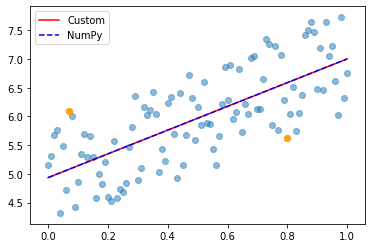

In [28]:
m, b = 2, 5
x = np.arange(0, 1.01, 0.01)
y = m * x + b + np.random.uniform(-1, 1, size=len(x))


#getting m and b from the custom least squares
m_f, b_f = least_squares(x, y)
A = np.vstack([x, np.ones(len(x))]).T

#now from numpy
m_np, b_np = np.linalg.lstsq(A, y, rcond=None)[0]


#calculating the difference between least squares and the actual equation
y_p = m_f * x + b_f
res = y - y_p
mx, mn = np.argmax(res), np.argmin(res)

y_p_np = m_np * x + b_np
res_np = y - y_p_np
mx_np, mn_np = np.argmax(res_np), np.argmin(res_np)

print("Custom Coefficients:", m_f, b_f)
print("NumPy Coefficients:", m_np, b_np)
print("Custom Max Res at:", x[mx], "=>", res[mx])
print("Custom Min Res at:", x[mn], "=>", res[mn])
print("NumPy Max Res at:", x[mx_np], "=>", res_np[mx_np])
print("NumPy Min Res at:", x[mn_np], "=>", res_np[mn_np])

#plotting
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_p, color='red', label='Custom')
plt.plot(x, y_p_np, color='blue', linestyle='--', label='NumPy')
plt.scatter([x[mx], x[mn]], [y[mx], y[mn]], color='orange')
plt.legend()
plt.show()

Both my custom least squared method and the built in numpy method find pretty much the same m and b, with the error being negligible. The m they find is equal to 2.066 and the b is equal to 4.93

This is close enough the to the original equation, considering that the data points are spread out due to the error applied.